# HW Submission [09/10/2025], Keith Fernandez
## High Performance Computing / GPU Programming, Fall 2025, Kean University

Consider the wave equation in its simplest form

$$
\frac{d^2}{dt^2} y = k \frac{d^2}{dx^2} y
$$

which can be expressed simply as "acceleration is proportional to curvature."

If you have a tight stretched string, and it is displaced, the string will attempt to restore to its rest state in such a way that areas that are more curved from straight will accelerate more towards a straight shape.

Suppose we have a stretched string, fixed at both ends from 0 to 10, with k = 1, and we want to solve this equation using the following pseudocode:

<pre>
n=2500 // approximate the string as being made up of n points
x = linspace(0,10,n) // space those points linearly from 0 to 10 in x
v = zeros(n) // set all velocities to zero
y = exp(-(x-5.0)**2) // start off the curvature with a bump
dvdt = zeros(n) // start off the string with no acceleration
store step size as dx = x[1]-x[0]
dxsquared = dx*dx

// run times from 0 to 10
tmin = 0
tmax = 10
// set timestep by dx (smaller dx needs smaller dt)
dt_ideal = 0.5*dx
// pick enough timesteps to get about that dt
nt = int(tmax/dt_ideal)+1
// linearly space time points
tgrid = linspace(tmin,tmax,nt)
// store dt
dt = tgrid[1]-tgrid[0]

k=1
for t in tgrid
 for i in 1 to n-2 (assuming 0 is array start)
   // use approximation to calculate curvature
   dvdt[i] = k*(y[i-1]+y[i+1]-2.0*y[i])/dxsquared
 for i in 0 to n-1
   // use dvdt to update v
   v[i] = v[i] + dvdt[i]*dt
 for i in 0 to n-1
   // use v = dydt to update y
   y[i] = y[i] + v[i]*dt
  
OUTPUT Y
</pre>

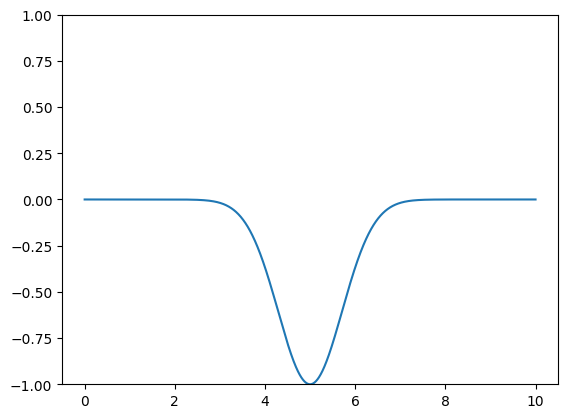

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Initialize parameters
n = 2500
x = np.linspace(0, 10, n)
v = np.zeros(n)
y = np.exp(-(x - 5.0)**2)
dvdt = np.zeros(n)
dx = x[1] - x[0]
dxsquared = dx * dx

tmin = 0
tmax = 10
dt_ideal = 0.5 * dx
nt = int(tmax / dt_ideal) + 1
n_frames = 100
nt = round(nt / n_frames) * n_frames
tgrid = np.linspace(tmin, tmax, nt)
dt = tgrid[1] - tgrid[0]

k = 1

# Initialize plot
fig, ax = plt.subplots()
line, = ax.plot(x, y)
ax.set_ylim(-1, 1)

# Total computational steps and frames to show
total_steps = nt
steps_per_frame = total_steps // n_frames  # Show n_frames frames

# Update function for animation
def update(frame):
    global y, v, dvdt

    for step in range(steps_per_frame):
        for i in range(1, n - 1):
            dvdt[i] = k * (y[i - 1] + y[i + 1] - 2.0 * y[i]) / dxsquared
        for i in range(n):
            v[i] = v[i] + dvdt[i] * dt
        for i in range(n):
            y[i] = y[i] + v[i] * dt

    line.set_ydata(y)
    return line,

# Create animation
ani = animation.FuncAnimation(fig, update, frames=100, init_func=lambda: [line], blit=True)

# Display the animation in the notebook
HTML(ani.to_jshtml())




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Initialize parameters
n = 2500
x = np.linspace(0, 10, n)
v = np.zeros(n)
y = np.exp(-(x - 5.0)**2)
dvdt = np.zeros(n)
dx = x[1] - x[0]
dxsquared = dx * dx

tmin = 0
tmax = 10
dt_ideal = 0.5 * dx
nt = int(tmax / dt_ideal) + 1
n_frames = 100
nt = round(nt / n_frames) * n_frames
tgrid = np.linspace(tmin, tmax, nt)
dt = tgrid[1] - tgrid[0]

k = 1


# Total computational steps and frames to show
total_steps = nt

# for every time
for time in tgrid:
    # for all non edge points
    for i in range(1, n - 1):
        dvdt[i] = k * (y[i - 1] + y[i + 1] - 2.0 * y[i]) / dxsquared
    # for all points
    for i in range(n):
        v[i] = v[i] + dvdt[i] * dt
    for i in range(n):
        y[i] = y[i] + v[i] * dt


print ( np.abs(y[int(n/2)]-(-1)) )




1.1827566871125406e-05


C code implementation of the pseudocode listed above.

In [6]:
%%writefile wavefunc.c

#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>

int main() {
    clock_t start_time = clock();
    clock_t end_time;
    double cpu_time;

    int n = 2500;
    double *x = malloc(n * sizeof(double));
    double *v = calloc(n, sizeof(double));
    double *y = malloc(n * sizeof(double));
    double *dvdt = calloc(n, sizeof(double));

    // Create linspace
    double x_min = 0.0, x_max = 10.0;
    double dx = (x_max - x_min) / (n - 1);
    for (int i = 0; i < n; i++) {
        x[i] = x_min + i * dx;
        double dx_shift = x[i] - 5.0;
        y[i] = exp(-(dx_shift * dx_shift));
    }
    double dxsquared = dx * dx;

    double tmax = 10.0;
    double dt_ideal = 0.5 * dx;
    int nt = (int)(tmax / dt_ideal) + 1;
    double dt = tmax / (nt - 1);

    double k = 1.0;

    // Time loop
    for (int step = 0; step < nt; step++) {
        // update accelerations
        for (int i = 1; i < n - 1; i++) {
            dvdt[i] = k * (y[i - 1] + y[i + 1] - 2.0 * y[i]) / dxsquared;
        }

        // update velocities
        for (int i = 0; i < n; i++) {
            v[i] += dvdt[i] * dt;
        }

        // update displacements
        for (int i = 0; i < n; i++) {
            y[i] += v[i] * dt;
        }
    }

    // Write final results to file
    FILE *fp = fopen("wave_output.csv", "w");
    if (!fp) {
        perror("File open failed");
        return 1;
    }
    fprintf(fp, "x,y\n");
    for (int i = 0; i < n; i++) {
        fprintf(fp, "%f,%f\n", x[i], y[i]);
    }
    fclose(fp);

    free(x);
    free(v);
    free(y);
    free(dvdt);

    end_time = clock();
    cpu_time = ((double)(end_time - start_time)) / CLOCKS_PER_SEC;
    printf("Time elapsed: %f seconds\n", cpu_time);
    printf("Results written to wave_output.csv\n");

    return 0;
}


Overwriting wavefunc.c


Needed to compile with `-lm` compiler flag for some of the math functions like `exp()` and `pow()`.

The C code writes to a `wavefunc.csv` file, to which we feed into Python via `pandas` and `matplotlib`. A plot is created to verify the program is behaving as expected.

An `-O3` compiler flag is used for allowing the `gcc` compiler to do optimizations on the program to save on time.

Time elapsed: 0.027837 seconds
Results written to wave_output.csv


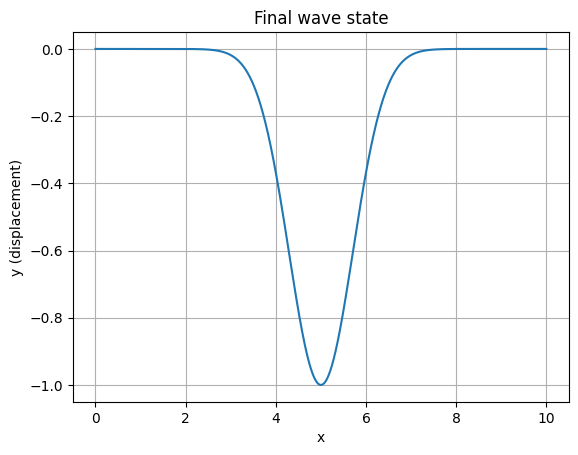

In [10]:
!gcc -O3 -Wall wavefunc.c -o wavefunc -lm
!./wavefunc

import pandas as pd
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv("wave_output.csv")

# Plot
plt.plot(df["x"], df["y"])
plt.xlabel("x")
plt.ylabel("y (displacement)")
plt.title("Final wave state")
plt.grid(True)
plt.show()